In this notebook I create datasets, dataloaders to train Seamese network model with ResNet50 backbones. Data with 3-lined patches used.

In [1]:
from google.colab import drive #upload data from google drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install torchvision

In [5]:
from torch.utils.data import Dataset
import random
import os
import cv2
import PIL
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torchvision.models as models
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F
from pathlib import Path
import numpy as np
import shutil
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from tqdm import tqdm


In [ ]:
def set_seed(seed=42):
    """Fix all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"All seeds fixed to {seed}")
set_seed(42)

In [7]:
#unzipping files
drive.mount('/content/drive')
import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/patches_output.zip', 'r') as z:
    z.extractall('/content/data')
DATA_ROOT = '/content/data/patches_output'
print(f"Authors: {len(os.listdir(DATA_ROOT))}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Authors: 657


Let's create class SiameseNetworkDataset for our data.
The dataset takes random pairs and create either positive (one author) or negative pair. The labels are created at random, the balance shall be ~50/50.
The pairs are created 'on the fly'.

In [8]:
class SiameseNetworkDataset(Dataset):
    def __init__(self, root, transform=None, train=True, size=100,
                 min_height=100, max_height=500, authors_list=None):
        self.transform = transform
        self.train = train
        self.size = size
        self.min_height = min_height
        self.max_height = max_height

        self.authors_data_positive = {}
        self.authors_data_all = {}

        # Если передан список авторов (для разделения train/val)
        if authors_list is not None:
            folders_to_scan = [f for f in os.listdir(root) if f in authors_list]
        else:
            folders_to_scan = os.listdir(root)

        for folder in folders_to_scan:
            author_path = os.path.join(root, folder)
            if not os.path.isdir(author_path):
                continue

            valid_images = []
            for file in os.listdir(author_path):
                if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    continue

                img_path = os.path.join(author_path, file)
                try:
                    with Image.open(img_path) as img:
                        height = img.size[1]
                    if self.min_height <= height <= self.max_height:
                        valid_images.append(file)
                except Exception:
                    continue

            if not valid_images:
                continue

            self.authors_data_all[author_path] = valid_images
            if len(valid_images) >= 2:
                self.authors_data_positive[author_path] = valid_images

        self.authors_paths_positive = list(self.authors_data_positive.keys())
        self.authors_paths_all = list(self.authors_data_all.keys())

        print(f"  Positive authors (>=2 images): {len(self.authors_paths_positive)}")
        print(f"  Total authors: {len(self.authors_paths_all)}")

        if len(self.authors_paths_positive) == 0:
            raise ValueError("No authors with at least 2 valid images!")

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        #creating labelfrom random.
        label = random.randint(0, 1)

        if label == 1:
            # Positive pair: same author
            author_path = random.choice(self.authors_paths_positive)
            images = self.authors_data_positive[author_path]
            img1_name, img2_name = random.sample(images, 2)
            img_path1 = os.path.join(author_path, img1_name)
            img_path2 = os.path.join(author_path, img2_name)

        else:
            #create negative pair
            if len(self.authors_paths_all) < 2:
                author_path = random.choice(self.authors_paths_positive)
                images = self.authors_data_positive[author_path]
                img1_name, img2_name = random.sample(images, 2)
                img_path1 = os.path.join(author_path, img1_name)
                img_path2 = os.path.join(author_path, img2_name)
                label = 1
            else:
                author1_path, author2_path = random.sample(self.authors_paths_all, 2)
                images1 = self.authors_data_all[author1_path]
                images2 = self.authors_data_all[author2_path]

                img1_name = random.choice(images1)
                img2_name = random.choice(images2)

                img_path1 = os.path.join(author1_path, img1_name)
                img_path2 = os.path.join(author2_path, img2_name)


        img1 = Image.open(img_path1).convert('L')
        img2 = Image.open(img_path2).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label


In [9]:
#splitting authors into train and val
import random
all_authors = [f for f in os.listdir(DATA_ROOT)
               if os.path.isdir(os.path.join(DATA_ROOT, f))]
random.shuffle(all_authors)

split_idx = int(len(all_authors) * 0.8)
train_authors = all_authors[:split_idx]
val_authors = all_authors[split_idx:]

print(f"Train authors: {len(train_authors)}, Val authors: {len(val_authors)}")

Train authors: 525, Val authors: 132


In [10]:
class ResizeTextPatch:
    """
    Adaptive resize of wide patches.
    Preserve propotions target_h × target_w.
    """
    def __init__(self, target_h=192, target_w=512):
        self.target_h = target_h
        self.target_w = target_w

    def __call__(self, img):
        w, h = img.size  # PIL: width, height

        # Calculating scale
        scale_h = self.target_h / h
        scale_w = self.target_w / w
        scale = min(scale_h, scale_w)

        new_w = int(w * scale)
        new_h = int(h * scale)

        # Resizing with interpolation
        img = TF.resize(img, [new_h, new_w], interpolation=TF.InterpolationMode.BICUBIC)

        # Creating black square
        new_img = Image.new('L', (self.target_w, self.target_h), 0)

        # Centerring the image
        paste_x = (self.target_w - new_w) // 2
        paste_y = (self.target_h - new_h) // 2
        new_img.paste(img, (paste_x, paste_y))

        return new_img

Let's create train and validation datasets, at train we will add some augmentation: a bit of rotation, shift, scaling

In [11]:
train_transform = T.Compose([

    ResizeTextPatch(target_h=384, target_w=1014),
    T.RandomRotation(3),
    T.RandomAffine(
        degrees=0,
        translate=(0.02, 0.02),
        scale=(0.98, 1.02)
    ),
    T.ToTensor(),
    T.Normalize(mean=[0.485], std=[0.229])  # ImageNet stats for 1 channel
])

val_transform = T.Compose([
    ResizeTextPatch(target_h=384, target_w=1014),
    T.ToTensor(),
    T.Normalize(mean=[0.485], std=[0.229])
])

In [12]:
train_dataset = SiameseNetworkDataset(
    root=DATA_ROOT,
    transform=train_transform,
    train=True,
    size=2500,
    min_height=100,
    max_height=500,
    authors_list=train_authors
)

val_dataset = SiameseNetworkDataset(
    root=DATA_ROOT,
    transform=val_transform,
    train=False,
    size=2000,
    min_height=100,
    max_height=500,
    authors_list=val_authors
)

  Positive authors (>=2 images): 422
  Total authors: 512
  Positive authors (>=2 images): 113
  Total authors: 132


Let's look at examples of our data in dataset

Lbael: 0
Size img1: torch.Size([1, 384, 1014])
Size img2: torch.Size([1, 384, 1014])


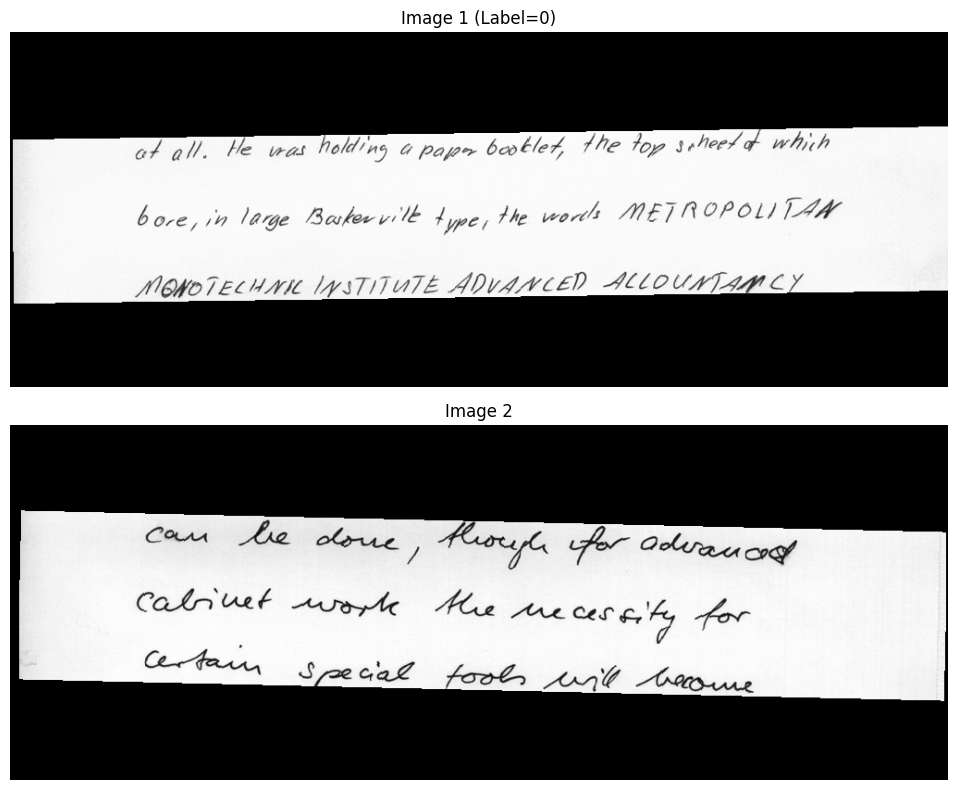

In [17]:
img1, img2, label = train_dataset[3]

print(f"Lbael: {label}")
print(f"Size img1: {img1.shape}")
print(f"Size img2: {img2.shape}")

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.imshow(img1[0], cmap='gray')
plt.title(f"Image 1 (Label={label})")
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(img2[0], cmap='gray')
plt.title("Image 2")
plt.axis('off')

plt.tight_layout()
plt.show()

Let's make sure that our train dataset is balanced

In [48]:
labels=[]

for i in range(len(train_dataset)):
  labels.append(train_dataset[i][2])

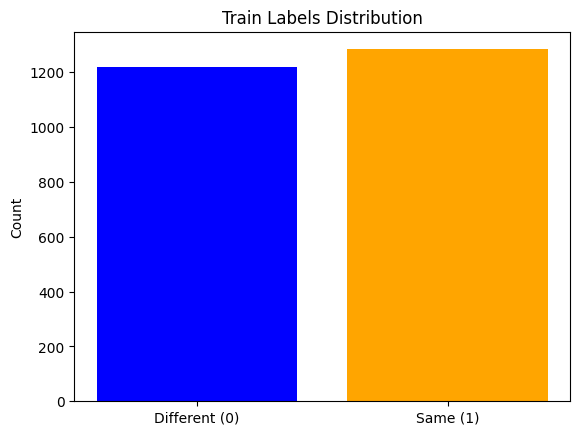

In [55]:
counts = [labels.count(0), labels.count(1)]

plt.bar(['Different (0)', 'Same (1)'], counts, color=['blue', 'orange'])
plt.ylabel('Count')
plt.title('Train Labels Distribution')
plt.show()

The number of negative and positive pairs is almost the same

In [20]:

# creating DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Let's create class of our model. The core of the model is ResNet50 architecture, after which there is embedding head, and binary classification layer (0 for negative pair and 1 for positive)

In [21]:
class SiameseNetwork(nn.Module):
    """Simple Siamese network - trained from scratch"""

    def __init__(self, embedding_size=256):
        super(SiameseNetwork, self).__init__()

        # Load ResNet-50 without pretrained weights
        self.resnet = models.resnet50(weights=None)

        # Adapt first layer for single channel
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Remove final FC layer
        self.resnet = nn.Sequential(*list(self.resnet.children())[:-1])

        # Embedding head
        self.embedding = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, embedding_size)
        )

        # Classifier
        self.classifier = nn.Linear(embedding_size, 1)

        self.embedding_size = embedding_size

        # Statistics
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Total parameters: {total:,}")
        print(f"Trainable parameters: {trainable:,} ({100*trainable/total:.1f}%)")

    #forward pass for one image
    def forward_one(self, x):
        x = self.resnet(x)
        x = x.view(x.size(0), -1)
        x = self.embedding(x)
        return F.normalize(x, p=2, dim=1)

    # forward pass for two images and making classification
    def forward(self, x1, x2):
        out1 = self.forward_one(x1)
        out2 = self.forward_one(x2)

        # L1 distance
        distance = torch.abs(out1 - out2)

        # classification logits
        logits = self.classifier(distance).squeeze(1)

        return logits, out1, out2

As loss function we will use combination of contrastive los and BCE. Let's cereate class for contrastive loss to train our model

In [22]:
class ContrastiveLoss(nn.Module):
    """Contrastive loss"""

    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # Eucledian distance
        distance = F.pairwise_distance(output1, output2)

        loss = label * torch.pow(distance, 2) / 2
        loss += (1 - label) * torch.pow(torch.clamp(self.margin - distance, min=0.0), 2) / 2

        return loss.mean()

Now let's create function for trainig our model. As

In [23]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=0.0003,
    device=None,
    save_path='best_model.pth'
):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = model.to(device)

    #creating optimizer and learning rate scheduler
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )
    #creating losses
    contrastive_loss = ContrastiveLoss(margin=1.0)
    bce_loss = nn.BCEWithLogitsLoss()

    #creating history to track results
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_roc_auc': [], 'val_roc_auc': [],
        'lr': []
    }
    best_val_roc_auc = 0.0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        train_labels = []
        train_preds = []

        #trainig cycle
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for img1, img2, labels in pbar:
            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.float().to(device)

            #making gradsients zero
            optimizer.zero_grad()
            #making prediction
            logits, emb1, emb2 = model(img1, img2)

            #calculating losses
            loss_contrastive = contrastive_loss(emb1, emb2, labels)
            loss_bce = bce_loss(logits, labels)
            loss = loss_contrastive + loss_bce

            #making step of GD
            loss.backward()
            optimizer.step()

            #calculating statistics
            train_loss += loss.item()
            probs = torch.sigmoid(logits)
            predicted = (probs > 0.5).float()
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)

            train_labels.extend(labels.cpu().numpy())
            train_preds.extend(probs.detach().cpu().numpy())

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{train_correct/train_total:.3f}'
            })

        #calculating metrics and loss for epoch
        train_acc = train_correct / train_total
        train_loss_avg = train_loss / len(train_loader)
        train_roc_auc = roc_auc_score(train_labels, train_preds)

        # validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_labels = []
        val_preds = []

        with torch.no_grad():
            for img1, img2, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                img1 = img1.to(device)
                img2 = img2.to(device)
                labels = labels.float().to(device)

                logits, emb1, emb2 = model(img1, img2)

                loss_contrastive = contrastive_loss(emb1, emb2, labels)
                loss_bce = bce_loss(logits, labels)
                loss = loss_contrastive + loss_bce

                val_loss += loss.item()
                probs = torch.sigmoid(logits)
                predicted = (probs > 0.5).float()
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

                val_labels.extend(labels.cpu().numpy())
                val_preds.extend(probs.cpu().numpy())

        val_acc = val_correct / val_total
        val_loss_avg = val_loss / len(val_loader)
        val_roc_auc = roc_auc_score(val_labels, val_preds)

        scheduler.step(val_loss_avg)

        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_roc_auc'].append(train_roc_auc)
        history['val_roc_auc'].append(val_roc_auc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss_avg:.4f}, Train Acc: {train_acc:.4f}, ROC-AUC: {train_roc_auc:.4f}")
        print(f"  Val Loss:   {val_loss_avg:.4f}, Val Acc:   {val_acc:.4f}, ROC-AUC: {val_roc_auc:.4f}")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

        if val_roc_auc > best_val_roc_auc:
            best_val_roc_auc = val_roc_auc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_roc_auc': val_roc_auc
            }, save_path)
            print(f"Model saved! ROC-AUC: {val_roc_auc:.4f}")

    return history

Starting training

In [24]:
model = SiameseNetwork(embedding_size=256)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Train
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.001,
    device=device,
    save_path='best_model_scratch.pth'
)

print(f"\nBest Val ROC-AUC: {max(history['val_roc_auc'])*100:.2f}%")

Total parameters: 24,682,433
Trainable parameters: 24,682,433 (100.0%)
Training from scratch (no pretrained weights)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [02:57<00:00,  1.41it/s]



Epoch 1/30
  Train Loss: 0.7635, Train Acc: 0.6208, ROC-AUC: 0.6424
  Val Loss:   0.9154, Val Acc:   0.5155, ROC-AUC: 0.6351
  LR: 0.001000
Model saved! ROC-AUC: 0.6351


Epoch 2/30 [Val]: 100%|██████████| 250/250 [02:56<00:00,  1.42it/s]



Epoch 2/30
  Train Loss: 0.7313, Train Acc: 0.6532, ROC-AUC: 0.7181
  Val Loss:   0.7937, Val Acc:   0.6540, ROC-AUC: 0.7615
  LR: 0.001000
Model saved! ROC-AUC: 0.7615


...


Epoch 7/30
  Train Loss: 0.6192, Train Acc: 0.7376, ROC-AUC: 0.7971
  Val Loss:   0.5695, Val Acc:   0.7535, ROC-AUC: 0.8603
  LR: 0.001000


Epoch 8/30 [Val]: 100%|██████████| 250/250 [02:56<00:00,  1.42it/s]



Epoch 8/30
  Train Loss: 0.6183, Train Acc: 0.7260, ROC-AUC: 0.7937
  Val Loss:   0.6297, Val Acc:   0.7155, ROC-AUC: 0.8125
  LR: 0.001000


Epoch 9/30 [Train]:   4%|▍         | 12/313 [00:27<11:28,  2.29s/it, loss=0.4871, acc=0.729]


KeyboardInterrupt: 

Our model trained up to 6 epoch with best validation accuracy 0.7985 and validation ROC AUC 0.8863, after that the model starts to overfit. Due to overfitting training was interrupted at epoch 8

In [29]:
checkpoint = torch.load('best_model_scratch.pth', weights_only=False) #saving the best checkpoint
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model with ROC-AUC: {checkpoint['val_roc_auc']:.4f}")

Loaded best model with ROC-AUC: 0.8863


Let's look at metrics and loss in graphs

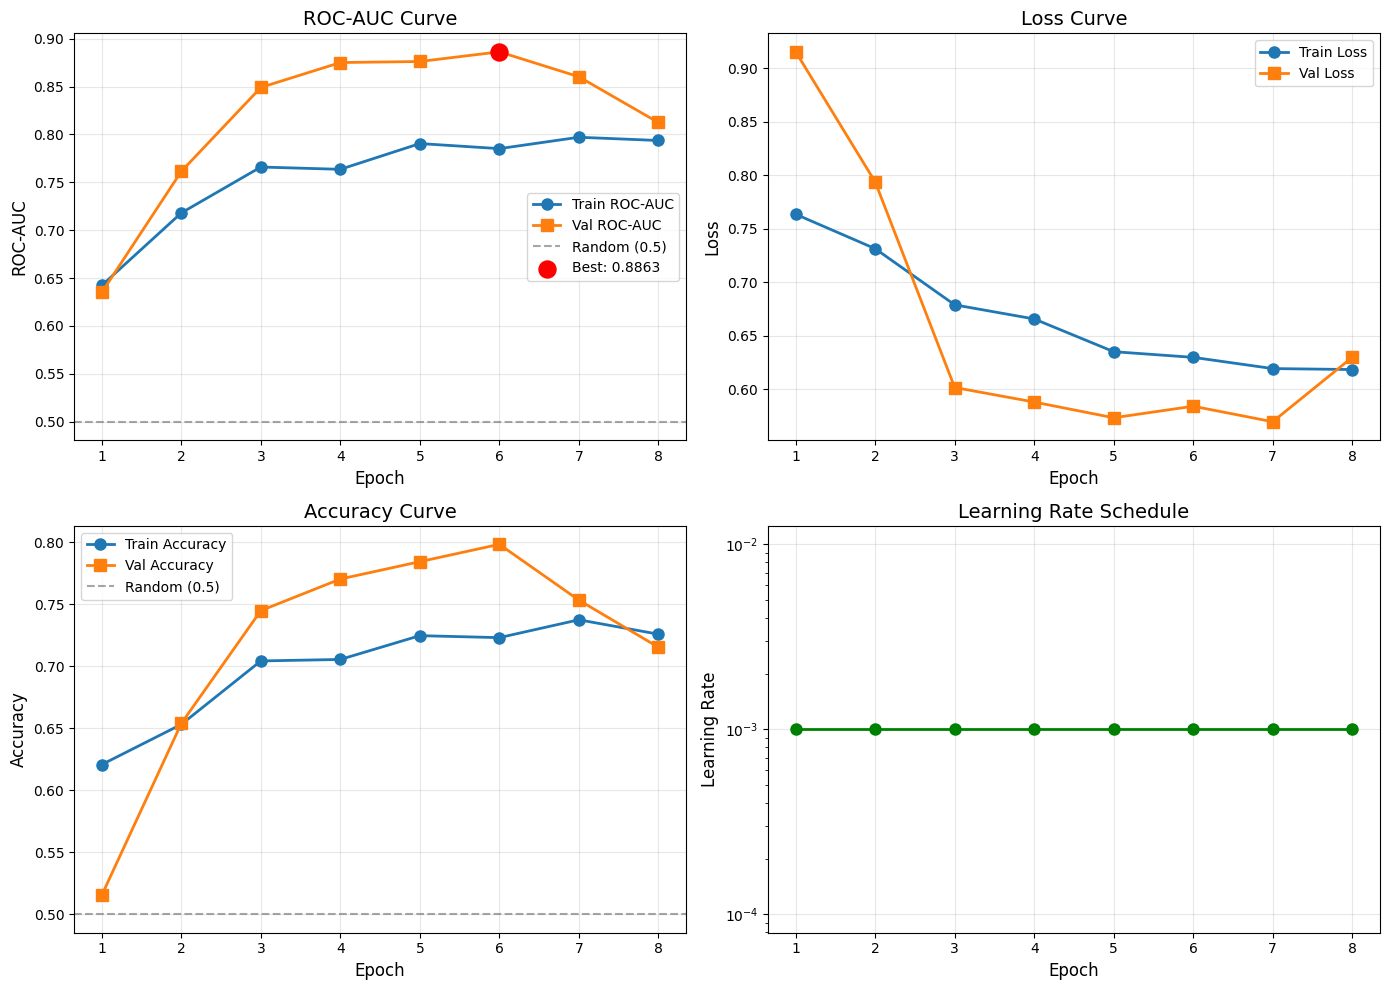


Best results:
Best Val ROC-AUC: 0.8863 (Epoch 6)
Best Val Accuracy: 0.7985 (Epoch 6)
Best Train ROC-AUC: 0.7971

Final values (Epoch 8):
Val ROC-AUC: 0.8125
Val Accuracy: 0.7155
Val Loss: 0.6297

Early stopping:
Model started overfitting after epoch 6
Training stopped after 8 epoch dut to model's overfitting


In [41]:
import matplotlib.pyplot as plt
import numpy as np

epochs = [1, 2, 3, 4, 5, 6, 7, 8]

train_loss = [0.7635, 0.7313, 0.6788, 0.6656, 0.6350, 0.6297, 0.6192, 0.6183]
val_loss = [0.9154, 0.7937, 0.6015, 0.5879, 0.5732, 0.5840, 0.5695, 0.6297]

train_acc = [0.6208, 0.6532, 0.7044, 0.7056, 0.7248, 0.7232, 0.7376, 0.7260]
val_acc = [0.5155, 0.6540, 0.7450, 0.7705, 0.7845, 0.7985, 0.7535, 0.7155]

train_roc_auc = [0.6424, 0.7181, 0.7660, 0.7636, 0.7905, 0.7852, 0.7971, 0.7937]
val_roc_auc = [0.6351, 0.7615, 0.8491, 0.8751, 0.8762, 0.8863, 0.8603, 0.8125]

lr = [0.001] * 8

history = {
    'train_loss': train_loss,
    'val_loss': val_loss,
    'train_acc': train_acc,
    'val_acc': val_acc,
    'train_roc_auc': train_roc_auc,
    'val_roc_auc': val_roc_auc,
    'lr': lr
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(epochs, train_roc_auc, 'o-', label='Train ROC-AUC', linewidth=2, markersize=8)
axes[0, 0].plot(epochs, val_roc_auc, 's-', label='Val ROC-AUC', linewidth=2, markersize=8)
axes[0, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random (0.5)')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('ROC-AUC', fontsize=12)
axes[0, 0].set_title('ROC-AUC Curve', fontsize=14)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)


best_epoch = val_roc_auc.index(max(val_roc_auc)) + 1
axes[0, 0].scatter(best_epoch, max(val_roc_auc), color='red', s=150, zorder=5,
                   label=f'Best: {max(val_roc_auc):.4f}')
axes[0, 0].legend(fontsize=10)

axes[0, 1].plot(epochs, train_loss, 'o-', label='Train Loss', linewidth=2, markersize=8)
axes[0, 1].plot(epochs, val_loss, 's-', label='Val Loss', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].set_title('Loss Curve', fontsize=14)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs, train_acc, 'o-', label='Train Accuracy', linewidth=2, markersize=8)
axes[1, 0].plot(epochs, val_acc, 's-', label='Val Accuracy', linewidth=2, markersize=8)
axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random (0.5)')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Accuracy', fontsize=12)
axes[1, 0].set_title('Accuracy Curve', fontsize=14)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs, lr, 'o-', color='green', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Learning Rate', fontsize=12)
axes[1, 1].set_title('Learning Rate Schedule', fontsize=14)
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_from_logs.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest results:")
print(f"Best Val ROC-AUC: {max(val_roc_auc):.4f} (Epoch {val_roc_auc.index(max(val_roc_auc)) + 1})")
print(f"Best Val Accuracy: {max(val_acc):.4f} (Epoch {val_acc.index(max(val_acc)) + 1})")
print(f"Best Train ROC-AUC: {max(train_roc_auc):.4f}")

print(f"\nFinal values (Epoch 8):")
print(f"Val ROC-AUC: {val_roc_auc[-1]:.4f}")
print(f"Val Accuracy: {val_acc[-1]:.4f}")
print(f"Val Loss: {val_loss[-1]:.4f}")

print(f"\nEarly stopping:")
print(f"Model started overfitting after epoch 6")
print(f"Training stopped after 8 epoch dut to model's overfitting")